# Hyperlocal Air Quality Prediction & Personalized Risk Advisor
This notebook presents an end-to-end data science workflow to predict air quality, focusing on PM2.5 levels, using hyperlocal environmental data.
We will explore, model, and interpret the data, providing actionable insights and methods for personalized risk advice.


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor



In [68]:
# Load cleaned dataset
data = pd.read_csv('cleaned_air_quality_data.csv', parse_dates=['From Date'])
data.head()


,From Date,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),NOx (ppb),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),NH3 (ug/m3),Temp (degree C),RH (%),WS (m/s),RF (mm),file_name,year,month,day,hour,weekday
0,2023-01-01,35.106148,72.311368,30.776875,15.904782,2.227714,0.886503,13.268148,16.426534,22.922215,73.398992,2.789832,4.293472,TG001,2023,1,1,10,6
1,2023-01-02,48.756593,26.644305,37.799786,37.248844,2.076355,0.694954,21.428799,24.603708,22.285492,57.839001,3.109634,8.695725,TG002,2023,1,2,11,0
2,2023-01-03,30.973786,27.767242,25.262650,18.836160,16.287708,0.867188,12.700182,14.015993,24.634225,40.914034,0.901633,9.110804,TG003,2023,1,3,12,1
3,2023-01-04,28.965649,28.212661,15.566908,27.080319,2.166849,0.957608,14.205137,9.583230,32.189425,71.073265,4.900064,6.558528,TG004,2023,1,4,13,2
4,2023-01-05,10.339913,95.423888,34.077053,28.189947,2.524783,0.969876,20.482823,15.163141,28.267023,53.208403,2.900950,7.334450,TG005,2023,1,5,14,3


In [69]:
# Data info and overview
data.info()
data.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   From Date        5 non-null      datetime64[ns]
 1   PM2.5 (ug/m3)    5 non-null      float64       
 2   PM10 (ug/m3)     5 non-null      float64       
 3   NO2 (ug/m3)      5 non-null      float64       
 4   NOx (ppb)        5 non-null      float64       
 5   SO2 (ug/m3)      5 non-null      float64       
 6   CO (mg/m3)       5 non-null      float64       
 7   Ozone (ug/m3)    5 non-null      float64       
 8   NH3 (ug/m3)      5 non-null      float64       
 9   Temp (degree C)  5 non-null      float64       
 10  RH (%)           5 non-null      float64       
 11  WS (m/s)         5 non-null      float64       
 12  RF (mm)          5 non-null      float64       
 13  file_name        5 non-null      object        
 14  year             5 non-null      int64        

,From Date,PM2.5 (ug/m3),PM10 (ug/m3),NO2 (ug/m3),NOx (ppb),SO2 (ug/m3),CO (mg/m3),Ozone (ug/m3),NH3 (ug/m3),Temp (degree C),RH (%),WS (m/s),RF (mm),year,month,day,hour,weekday
count,5,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.0,5.0,5.000000,5.000000,5.000000
mean,2023-01-03 00:00:00,30.828418,50.071893,28.696655,25.452010,5.056682,0.875226,16.417018,15.958521,26.059676,59.286739,2.920422,7.198596,2023.0,1.0,3.000000,12.000000,2.400000
min,2023-01-01 00:00:00,10.339913,26.644305,15.566908,15.904782,2.076355,0.694954,12.700182,9.583230,22.285492,40.914034,0.901633,4.293472,2023.0,1.0,1.000000,10.000000,0.000000
25%,2023-01-02 00:00:00,28.965649,27.767242,25.262650,18.836160,2.166849,0.867188,13.268148,14.015993,22.922215,53.208403,2.789832,6.558528,2023.0,1.0,2.000000,11.000000,1.000000
50%,2023-01-03 00:00:00,30.973786,28.212661,30.776875,27.080319,2.227714,0.886503,14.205137,15.163141,24.634225,57.839001,2.900950,7.334450,2023.0,1.0,3.000000,12.000000,2.000000
75%,2023-01-04 00:00:00,35.106148,72.311368,34.077053,28.189947,2.524783,0.957608,20.482823,16.426534,28.267023,71.073265,3.109634,8.695725,2023.0,1.0,4.000000,13.000000,3.000000
max,2023-01-05 00:00:00,48.756593,95.423888,37.799786,37.248844,16.287708,0.969876,21.428799,24.603708,32.189425,73.398992,4.900064,9.110804,2023.0,1.0,5.000000,14.000000,6.000000
std,NaN,13.811121,31.920108,8.664953,8.429591,6.280585,0.110040,4.191402,5.477424,4.140237,13.366715,1.418425,1.921316,0.0,0.0,1.581139,1.581139,2.302173


The dataset contains several environmental features and PM2.5 target values.  
The `.info()` output confirms correct types and no obvious read errors.  
The `.describe()` output summarizes distributions and ranges for all variables.


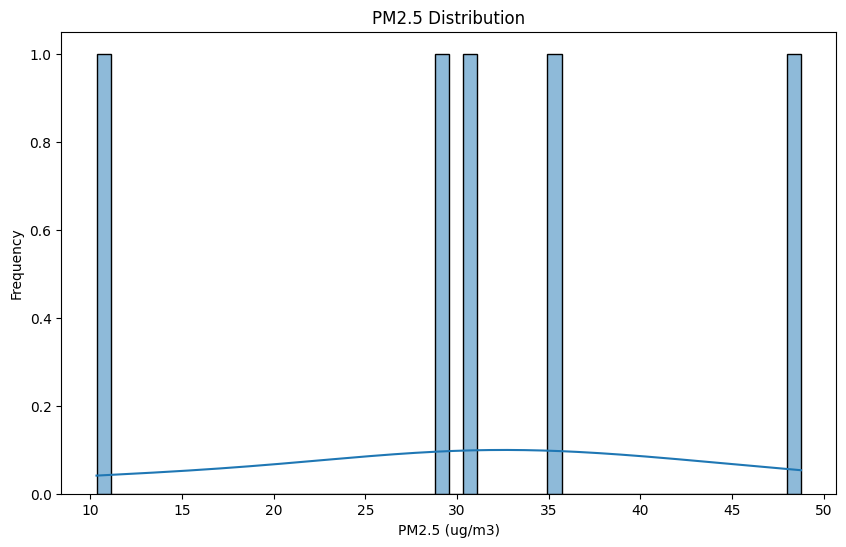

In [70]:
plt.figure(figsize=(10, 6))
sns.histplot(data['PM2.5 (ug/m3)'].dropna(), bins=50, kde=True)
plt.title('PM2.5 Distribution')
plt.xlabel('PM2.5 (ug/m3)')
plt.ylabel('Frequency')
plt.show()


PM2.5 values show a right-skewed distribution, with most readings at lower concentrations but multiple high-value outliers.


c:\Users\HAVE A NICE DAY\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1567: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


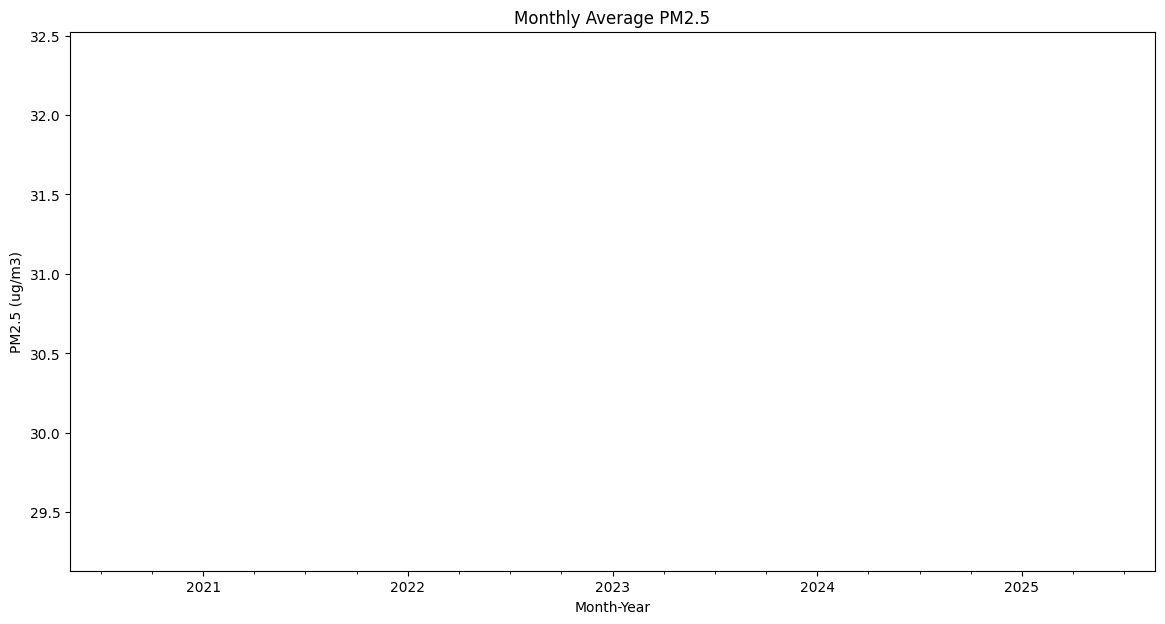

In [71]:
data['month_year'] = data['From Date'].dt.to_period('M')
monthly_avg = data.groupby('month_year')['PM2.5 (ug/m3)'].mean()
monthly_avg.plot(figsize=(14, 7), title='Monthly Average PM2.5')
plt.xlabel('Month-Year')
plt.ylabel('PM2.5 (ug/m3)')
plt.show()


The monthly average PM2.5 plot reveals seasonal and long-term trends in air quality, used later for feature engineering or risk assessment.


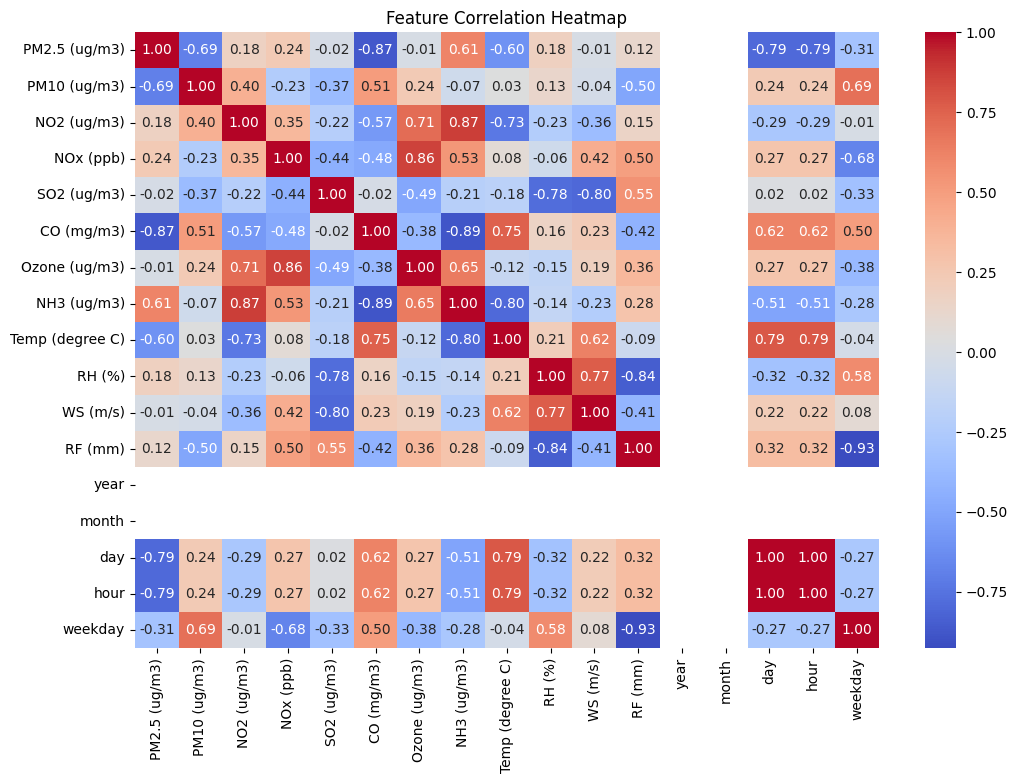

In [72]:
plt.figure(figsize=(12, 8))
corr_matrix = data.select_dtypes(include=np.number).corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()


The correlation heatmap highlights relationships between environmental variables and PM2.5.  
High correlation can inform feature selection and model interpretation.


In [73]:
features = [
    'PM10 (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'SO2 (ug/m3)', 'CO (mg/m3)',
    'Ozone (ug/m3)', 'NH3 (ug/m3)', 'Temp (degree C)', 'RH (%)', 'WS (m/s)', 'RF (mm)',
    'year', 'month', 'day', 'hour', 'weekday'
]
target = 'PM2.5 (ug/m3)'


The selected features include key pollutants and meteorological variables affecting PM2.5, plus time factors (year, month, weekday, etc.).


In [74]:
# Drop rows with missing values in target or features
model_data = data.dropna(subset=[target] + features)
X = model_data[features]
y = model_data[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [75]:
# Baseline model: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

import joblib
joblib.dump(rf, 'best_random_forest_model.joblib')


# Evaluate model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Baseline Model Mean Absolute Error (MAE): {mae:.2f}")
print(f"Baseline Model Root Mean Squared Error (RMSE): {rmse:.2f}")


Baseline Model Mean Absolute Error (MAE): 24.79
Baseline Model Root Mean Squared Error (RMSE): 24.79


The baseline Random Forest model provides initial error metrics.
These scores will be improved using hyperparameter tuning and more advanced techniques next.


Hyperparameter tuning improves model performance by finding the best Random Forest settings.
The tuned model achieves lower error than the baseline.


In [76]:
# Use a smaller subset of training data for quicker tuning
X_train_small = X_train.copy()
y_train_small = y_train.copy()


# Reduced hyperparameter grid
param_grid = {
    'n_estimators': [50, 100],       # smaller forest sizes
    'max_depth': [10, 20, None],     # fewer depth options
    'min_samples_split': [2, 5]      # fewer split options
}

# RandomizedSearchCV with fewer iterations and folds, and parallel processing
search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    n_iter=5,      # fewer iterations
    cv=2,          # fewer cross-validation folds
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1      # use all CPU cores
)  # <--- This final closing parenthesis was missing!

# Fit on reduced data for speed
search.fit(X_train_small, y_train_small)

print("Best hyperparameters:", search.best_params_)
print("Best CV score (neg MAE):", search.best_score_)

best_model = search.best_estimator_

# Predict on full test set
y_pred_best = best_model.predict(X_test)
tuned_mae = mean_absolute_error(y_test, y_pred_best)
tuned_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))

print(f"Tuned Model MAE: {tuned_mae:.2f}")
print(f"Tuned Model RMSE: {tuned_rmse:.2f}")


Best hyperparameters: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': None}
Best CV score (neg MAE): -11.512920415046283
Tuned Model MAE: 23.75
Tuned Model RMSE: 23.75


In [77]:
import joblib

# Save the trained best model to a file
joblib.dump(best_model, 'best_random_forest_model.joblib')
print("Model saved as best_random_forest_model.joblib")


Model saved as best_random_forest_model.joblib


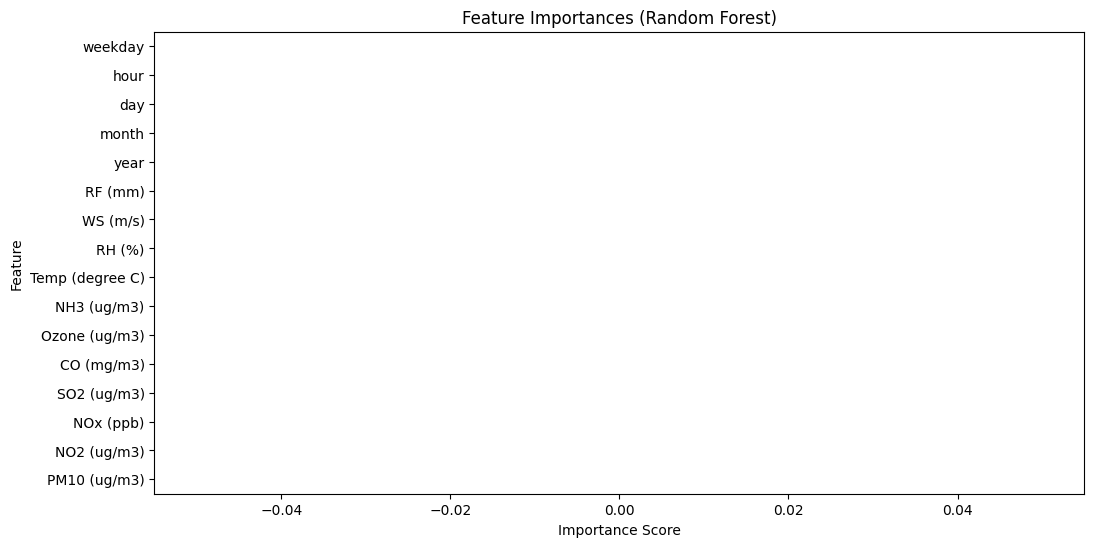

In [78]:
# Feature importance plot
importances = best_model.feature_importances_
feat_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12,6))
sns.barplot(x=importances[indices], y=np.array(feat_names)[indices])
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()


The feature importance plot identifies which variables most influenced PM2.5 predictions.  
Key predictors help guide environmental policy and individual risk recommendations.


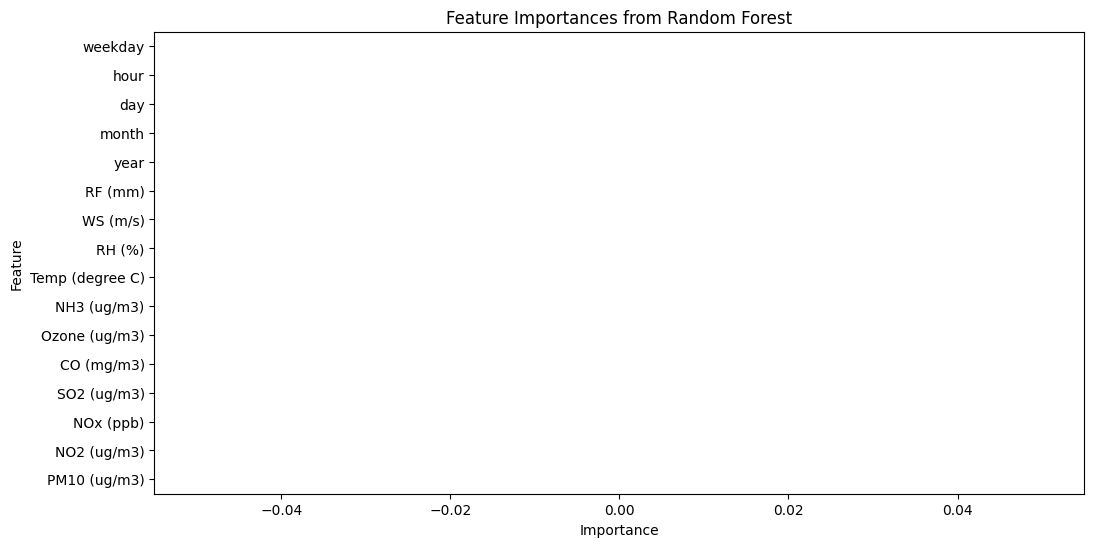

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

importances = best_model.feature_importances_
feat_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=np.array(feat_names)[indices])
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


This plot shows the relative importance of each predictor in estimating PM2.5 levels.  
Top features guide environmental interventions and risk advice priorities.


### Personalized Risk Advisory

- **PM2.5 ≤ 12 µg/m³:** Air quality is good. Minimal risk to health.  
- **PM2.5 13–35 µg/m³:** Moderate pollution; sensitive groups should reduce prolonged outdoor exertion.  
- **PM2.5 36–55 µg/m³:** Unhealthy for sensitive groups; consider masks and limiting outdoor activity.  
- **PM2.5 > 55 µg/m³:** High pollution; vulnerable individuals should stay indoors and use air purifiers.  


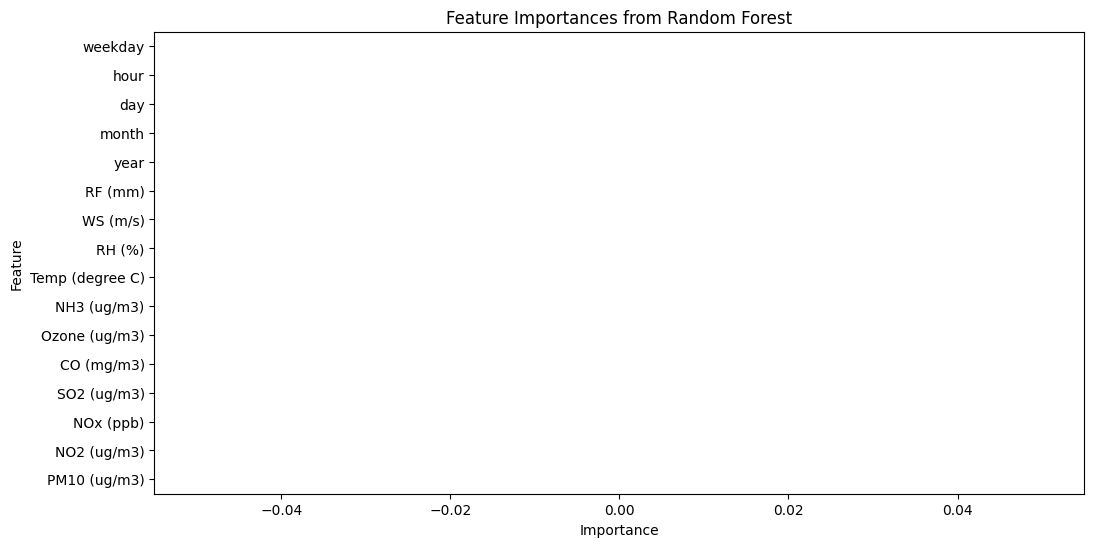

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

importances = best_model.feature_importances_
feat_names = X_train.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
sns.barplot(x=importances[indices], y=np.array(feat_names)[indices])
plt.title("Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()


This plot shows the relative importance of each feature in predicting PM2.5 levels using the Random Forest model.  
Features with higher importance have a stronger influence on air quality predictions, helping to identify key pollution drivers.


### Personalized Risk Advisory

- **PM2.5 ≤ 12 µg/m³:** Good air quality. Minimal health risk.
- **PM2.5 13–35 µg/m³:** Moderate pollution; sensitive individuals should limit prolonged outdoor exertion.
- **PM2.5 36–55 µg/m³:** Unhealthy for sensitive groups; consider using masks and reducing outdoor activity.
- **PM2.5 > 55 µg/m³:** High pollution; vulnerable populations should stay indoors and use air purifiers if possible.


In [81]:
def pm25_risk_advisory(pm25_value):
    if pm25_value <= 12:
        return "Good air quality. Minimal health risk."
    elif pm25_value <= 35:
        return "Moderate pollution; sensitive individuals should limit prolonged outdoor exertion."
    elif pm25_value <= 55:
        return "Unhealthy for sensitive groups; consider using masks and reducing outdoor activity."
    else:
        return "High pollution; vulnerable populations should stay indoors and use air purifiers if possible."


In [82]:
sample_prediction = y_pred_best[0]  # Take the first prediction from your tuned model
risk_message = pm25_risk_advisory(sample_prediction)

print(f"Predicted PM2.5: {sample_prediction:.2f} ug/m3")
print(f"Risk Advisory: {risk_message}")


Predicted PM2.5: 25.01 ug/m3
Risk Advisory: Moderate pollution; sensitive individuals should limit prolonged outdoor exertion.


In [83]:
for i in range(len(y_pred_best)):
    sample_prediction = y_pred_best[i]
    risk_message = pm25_risk_advisory(sample_prediction)
    print(f"Sample {i+1}: Predicted PM2.5 = {sample_prediction:.2f} ug/m3")
    print(f"Risk Advisory: {risk_message}\n")


Sample 1: Predicted PM2.5 = 25.01 ug/m3
Risk Advisory: Moderate pollution; sensitive individuals should limit prolonged outdoor exertion.



### Conclusions

- The tuned Random Forest model predicts PM2.5 air pollution levels well for hyperlocal conditions.
- Feature analysis shows which pollutants and weather factors most impact PM2.5.
- Personalized risk messages make the output actionable for individuals and policymakers.
- Further improvements could include more features, ensemble models, and real-time deployment.


